# Load and pre-process data

In [ ]:
import pandas as pd

path_data = 'data/spanish_subset/'
df_train = pd.read_csv(path_data + 'train.csv')
df_test = pd.read_csv(path_data + 'test.csv')

# Keep only stereohoax data
df_train = df_train[df_train['source'] == 'stereohoax']
df_test = df_test[df_test['source'] == 'stereohoax']

"""
Explanation of the columns
- text: tweet
- level1: previous sentence, only for "detests" dataset, not relevant for steareohoax
- level2: previous tweet. 0 if none
- level3: first tweet
- level4: racial hoax, see level4 table for the content of these hoaxes
- stereotype_a1/2/3: binary label for stereotype presence, annotator 1/2/3
- stereotype: binary label for stereotype presence, majority voting between all three annotators
- stereotype_soft: softmax normalization of stereotype label
- implicit_a1/2/3: binary label for implicitness, annotator 1/2/3
- implicit: binary label for implicitness, majority voting between all three annotators
- implicit_soft: softmax normalization of implicitness label
"""

print(f"Training dataset shape: {df_train.shape}")
print(f"Testing dataset shape: {df_test.shape}")
df_train.head(2)

Training dataset shape: (4277, 18)
Testing dataset shape: (1072, 18)


,source,id,comment_id,text,level1,level2,level3,level4,stereotype_a1,stereotype_a2,stereotype_a3,stereotype,stereotype_soft,implicit_a1,implicit_a2,implicit_a3,implicit,implicit_soft
5629,stereohoax,s_0,s_0,"El @user recuperará la ""sanidad universal"" y o...",0,0,s_0,SP003,1,1,1,1,0.9526,1,0,0,0,0.2689
5630,stereohoax,s_1,s_1,"El PSOE recuperará la ""sanidad universal"" y ob...",0,0,s_1,SP003,1,1,1,1,0.9526,1,0,0,0,0.2689


In [2]:
# Match level4 4 hoaxes indices with actual textual hoaxes

hoaxes = pd.read_csv(path_data + 'hoaxes.csv', header=1).rename(columns={'id': 'level4', 'text': 'hoax'})

df_train = df_train.merge(hoaxes, on='level4', how='inner')
df_test = df_test.merge(hoaxes, on='level4', how='inner')

# Baseline Model (thread only, no context)

In [ ]:
# Reduce size of training and testing dataset to limit computation time on CPU
# Also balance classes 

def stratified_sample(df, n):
    return df.groupby('stereotype', group_keys=False).apply(lambda x: x.sample(min(len(x), n // 2), random_state=42))


n_train = 400
n_test = 60

df_train = stratified_sample(df_train, n_train)
df_test = stratified_sample(df_test, n_test)

C:\Users\DavidBrantschen\AppData\Local\Temp\ipykernel_21284\2254656998.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('stereotype', group_keys=False).apply(lambda x: x.sample(min(len(x), n // 2), random_state=42))
C:\Users\DavidBrantschen\AppData\Local\Temp\ipykernel_21284\2254656998.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('stereotype', group_keys=False).apply(lamb

In [4]:
from datasets import Dataset

# Keep only relevant columns
df_train = df_train[['text', 'stereotype']]
df_test = df_test[['text', 'stereotype']]

# Convert to HuggingFace Dataset
train_dataset = Dataset.from_pandas(df_train.reset_index(drop=True))
test_dataset = Dataset.from_pandas(df_test.reset_index(drop=True))

In [5]:
# Tokenize
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=128)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

"""
The tokenizer returns:
- text: original raw input (not used by the model, kept for reference)
- stereotype: label/ground truth, kept as is
- input_ids: indices of tokens representing the input text
- attention_mask: differentiates between real tokens and padding (transformers process fixed-length sequences)
"""

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

'\nThe tokenizer returns:\n- text: original raw input (not used by the model, kept for reference)\n- stereotype: label/ground truth, kept as is\n- input_ids: indices of tokens representing the input text\n- attention_mask: differentiates between real tokens and padding (transformers process fixed-length sequences)\n'

In [6]:
# Format for Pytorch
train_dataset = train_dataset.rename_column("stereotype", "labels")
test_dataset = test_dataset.rename_column("stereotype", "labels")

# Convert data to tensors
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

In [7]:
# Load model
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=2
)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
# Training setup
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    save_strategy="epoch",
    logging_dir="./logs",
)

In [ ]:
# Metrics
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_binary": f1_score(labels, preds),
        "f1_class0": f1_score(labels, preds, pos_label=0),
        "f1_class1": f1_score(labels, preds, pos_label=1),
    }

In [10]:
# Trainer
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

C:\Users\DavidBrantschen\AppData\Local\Temp\ipykernel_21284\766726223.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [11]:
# Train
trainer.train()

c:\Users\DavidBrantschen\anaconda3\envs\ada\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Binary
1,0.715300,0.694874,0.500000,0.333333,0.666667
2,0.617600,0.574200,0.716667,0.714685,0.738462
3,0.487700,0.607231,0.666667,0.657143,0.714286


c:\Users\DavidBrantschen\anaconda3\envs\ada\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\DavidBrantschen\anaconda3\envs\ada\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=75, training_loss=0.6068771107991536, metrics={'train_runtime': 930.0655, 'train_samples_per_second': 1.29, 'train_steps_per_second': 0.081, 'total_flos': 78933316608000.0, 'train_loss': 0.6068771107991536, 'epoch': 3.0})

In [14]:
preds_output = trainer.predict(test_dataset)
preds = preds_output.predictions.argmax(axis=1)

import numpy as np
print("Predictions distribution:", np.bincount(preds))
print("Labels distribution:", np.bincount(preds_output.label_ids))

c:\Users\DavidBrantschen\anaconda3\envs\ada\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Predictions distribution: [20 40]
Labels distribution: [30 30]


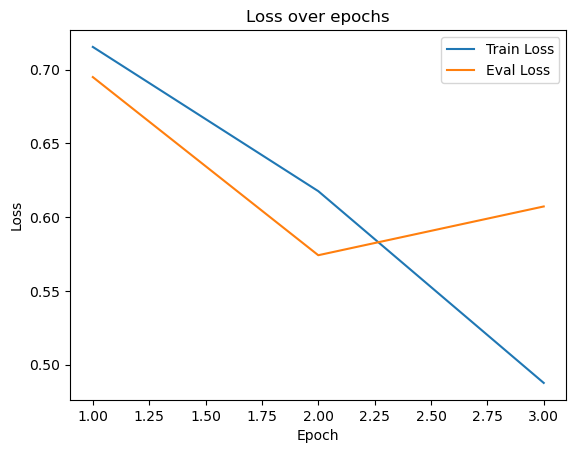

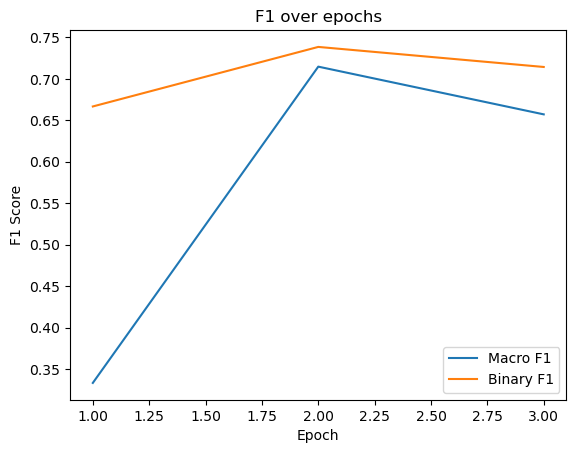

In [13]:
import matplotlib.pyplot as plt

# Get logs
logs_df = pd.DataFrame(trainer.state.log_history)

# Training loss
train_loss = logs_df[logs_df["loss"].notna()]

# Evaluation metrics
eval_df = logs_df[logs_df["eval_loss"].notna()]

# Plot loss
plt.figure()
plt.plot(train_loss["epoch"], train_loss["loss"], label="Train Loss")
plt.plot(eval_df["epoch"], eval_df["eval_loss"], label="Eval Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over epochs")
plt.show()

# Plot F1
plt.figure()
plt.plot(eval_df["epoch"], eval_df["eval_f1_macro"], label="Macro F1")
plt.plot(eval_df["epoch"], eval_df["eval_f1_binary"], label="Binary F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.legend()
plt.title("F1 over epochs")
plt.show()


# Context-Aware Model
Instead of using the tweet, use also the previous tweet and the parent tweet (and eventually also the hoax?)

In [79]:
# Read data
path_data = 'data/spanish_subset/'
df_train = pd.read_csv(path_data + 'train.csv')
df_test = pd.read_csv(path_data + 'test.csv')

# Keep only stereohoax data
df_train = df_train[df_train['source'] == 'stereohoax']
df_test = df_test[df_test['source'] == 'stereohoax']

In [80]:
# Replace ids of parent and root tweets by actual textual tweet

def ids_to_text(df):
    id_to_text = df[['comment_id', 'text']].rename(columns={'comment_id': 'lookup_id', 'text': 'lookup_text'})

    df = df.merge(
        id_to_text,
        left_on='level2',
        right_on='lookup_id',
        how='left'
    ).rename(columns={'lookup_text': 'parent_text'}).drop(columns=['lookup_id'])
    
    df = df.merge(
        id_to_text,
        left_on='level3',
        right_on='lookup_id',
        how='left'
    ).rename(columns={'lookup_text': 'root_text'}).drop(columns=['lookup_id'])

    # Some tweets might not have parent or root tweets
    df['parent_text'] = df['parent_text'].fillna("")
    df['root_text'] = df['root_text'].fillna("")

    return df

df_train = ids_to_text(df_train)
df_test = ids_to_text(df_test)

In [81]:
# Reduce size of training and testing dataset to limit computation time on CPU
# Also balance classes 

def stratified_sample(df, n):
    return df.groupby('stereotype', group_keys=False).apply(lambda x: x.sample(min(len(x), n // 2), random_state=42))


n_train = 200
n_test = 50

df_train = stratified_sample(df_train, n_train)
df_test = stratified_sample(df_test, n_test)

C:\Users\DavidBrantschen\AppData\Local\Temp\ipykernel_21284\3638080068.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('stereotype', group_keys=False).apply(lambda x: x.sample(min(len(x), n // 2), random_state=42))
C:\Users\DavidBrantschen\AppData\Local\Temp\ipykernel_21284\3638080068.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('stereotype', group_keys=False).apply(lamb

In [82]:
# Keep only relevant columns
df_train = df_train[['text', 'parent_text', 'root_text', 'stereotype']]
df_test = df_test[['text', 'parent_text', 'root_text', 'stereotype']]

# Convert to HuggingFace Dataset
train_dataset = Dataset.from_pandas(df_train.reset_index(drop=True))
test_dataset = Dataset.from_pandas(df_test.reset_index(drop=True))

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

In [83]:
# Context-aware tokenization
def tokenize(example):
    combined = [
        r + " </s> " + p + " </s> " + t
        for r, p, t in zip(example["root_text"], example["parent_text"], example["text"])
    ]

    return tokenizer(
        combined,
        truncation=True,
        padding="max_length",
        max_length=512
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [84]:
# Format for Pytorh
train_dataset = train_dataset.rename_column("stereotype", "labels")
test_dataset = test_dataset.rename_column("stereotype", "labels")

# Convert to tensors
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

In [85]:
# Load model (same as for the base model)
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=2
)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [86]:
# Training setup
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    save_strategy="epoch",
    logging_dir="./logs",
)

In [87]:
# Metrics
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_binary": f1_score(labels, preds),
        "f1_class0": f1_score(labels, preds, pos_label=0),
        "f1_class1": f1_score(labels, preds, pos_label=1),
    }

In [88]:
# Trainer
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

C:\Users\DavidBrantschen\AppData\Local\Temp\ipykernel_21284\766726223.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [89]:
trainer.train()

c:\Users\DavidBrantschen\anaconda3\envs\ada\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Binary,F1 Class0,F1 Class1
1,0.699600,0.691867,0.500000,0.333333,0.000000,0.666667,0.000000
2,0.679100,0.687320,0.560000,0.509804,0.352941,0.666667,0.352941


c:\Users\DavidBrantschen\anaconda3\envs\ada\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=26, training_loss=0.6893708889301007, metrics={'train_runtime': 2810.4252, 'train_samples_per_second': 0.142, 'train_steps_per_second': 0.009, 'total_flos': 105244422144000.0, 'train_loss': 0.6893708889301007, 'epoch': 2.0})